In [29]:
pip install tensorflow numpy matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow:",tf.__version__)

TensorFlow: 2.21.0


In [31]:
corpus = """
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies in text
gru is faster and simpler than lstm but performs similarly
text generation models predict the next word in a sequence
deep learning models can generate meaningful sentences
vanilla rnn struggles with long term dependencies due to vanishing gradients
lstm uses forget input and output gates to control memory flow
gru uses a reset gate and an update gate instead of three separate gates
attention mechanisms later improved on rnn and lstm based models
transformers replaced recurrent networks in most modern nlp systems
neural networks learn patterns directly from large amounts of data
sequence models are widely used in machine translation and chatbots
recurrent connections allow networks to remember information from previous steps
backpropagation through time is used to train recurrent neural networks
"""
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies in text
gru is faster and simpler than lstm but performs similarly
text generation models predict the next word in a sequence
deep learning models can generate meaningful sentences
vanilla rnn struggles with long term dependencies due to vanishing gradients
lstm uses forget input and output gates to control memory flow
gru uses a reset gate and an update gate instead of three separate gates
attention mechanisms later improved on rnn and lstm based models
transformers replaced recurrent networks in most modern nlp systems
neural networks learn patterns directly from large amounts of data
sequence models are widely used in machine translation and chatbots
recurrent connections allow networks to remember information from previous steps
backpropagation through time is used to train recurrent neural networks




>i have changed the corpus to more characters having rich vocabulary which is more intresting

In [32]:
token=Tokenizer()
token.fit_on_texts([corpus])
total_words=len(token.word_index)+1
print("Vocabulary size:",total_words)
input_sequences=[]
for line in corpus.split('\n'):
    token_list=token.texts_to_sequences([line])[0]
    for i in range(1,len(token_list)):
        n_gram_seq=token_list[:i+1]
        input_sequences.append(n_gram_seq)
max_len=max(len(seq) for seq in input_sequences)
input_sequences=pad_sequences(input_sequences,maxlen=max_len,padding='pre')
X = input_sequences[:,:-1]   # everything except the last token=input
y = input_sequences[:,-1]    # the last token=the word to predict
print("Total training sequences:",len(input_sequences))
print("X shape:",X.shape)
print("y shape:",y.shape)
print("Max sequence length:",max_len)

Vocabulary size: 99
Total training sequences: 129
X shape: (129, 13)
y shape: (129,)
Max sequence length: 14


- here we are doing the Tokenization which converts words to integers as neural networks understand only numeric data
- then we are creating n gram sequences this helps in next word prediction
- here in the total words we are performing +1 due to reserved padding

### Model 1-Vanilla RNN


**The architecture of this vanilla rnn is:**
- `Embedding`
- `SimpleRNN(64)`
- `Dense(total_words, softmax)`

In [33]:
rnn_model = Sequential([
    Input(shape=(max_len-1,)),
    Embedding(total_words,32),
    SimpleRNN(128),
    Dense(total_words,activation='softmax')
])
rnn_model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
rnn_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 13, 32)         │         3,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 99)             │        12,771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,547 (142.76 KB)

 Trainable params: 36,547 (142.76 KB)

 Non-trainable params: 0 (0.00 B)

- here i changes the no of hidden units to double of the original units i.e 64 
- Now the model has 128 memory cells,allowing it to learn more complex patterns.

### Train the RNN


In [34]:
rnn_history = rnn_model.fit(X, y,epochs=200,verbose=1)
print("Vanilla RNN")
print("Final loss:",round(rnn_history.history['loss'][-1],4))
print("Final accuracy:",round(rnn_history.history['accuracy'][-1],4))

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0310 - loss: 4.6059      
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0543 - loss: 4.5278
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0233 - loss: 4.4808
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0155 - loss: 4.4645    
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0155 - loss: 4.4952    
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0233 - loss: 4.4787
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0233 - loss: 4.3630
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0233 - loss: 4.2714
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0310 - loss: 4.1997
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0388 - loss: 4.1196
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0930 - loss: 4.0387
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1473 - 

- here i tweaked the no of epochs to 200 which decreased the loss and the accuracy dropped to 0.94 which was 0.96 with 100 epochs

- and i changed the verbose to 1 which shows loss and accuracy of each epoch

###  Model 2—LSTM (Long Short-Term Memory)

LSTM fixes the vanishing-gradient problem with a **cell state** which is a separate memory lane running alongside the hidden state and three gates that control it
- **Forget gate** — it decides what to throw away from the cell state
- **Input gate** — it decides what new information to add
- **Output gate** — it decides what part of the cell state to expose as the hidden state at this step

In [35]:
lstm_model=Sequential([
    Input(shape=(max_len-1,)),
    Embedding(total_words,64),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 13, 64)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 99)             │        12,771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,923 (460.64 KB)

 Trainable params: 117,923 (460.64 KB)

 Non-trainable params: 0 (0.00 B)

- here i changed the no of hidden states to 128 
- and increased the embedding dimension to 64

In [36]:
lstm_history=lstm_model.fit(X,y,epochs=200,verbose=1)
print("LSTM")
print("Final loss:",round(lstm_history.history['loss'][-1], 4))
print("Final accuracy:",round(lstm_history.history['accuracy'][-1], 4))

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0078 - loss: 4.5955      
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1008 - loss: 4.5822
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0543 - loss: 4.5705 
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 4.5478     
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 4.4935     
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 4.4839     
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 4.5847     
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 4.6097     
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0233 - loss: 4.5246 
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0233 - loss: 4.4291 
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 4.3723    
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/st

- here with no of hidden states=64 and embedding dimension=32 
- Final loss: 0.7567
- Final accuracy: 0.938

- with no of hidden states=128 and embedding dimension=64
- Final loss: 0.1413
- Final accuracy: 0.9612

- so we can say the larger embeddings capture richer semantics

### Model 3—GRU (Gated Recurrent Unit)

GRU is a simplification of LSTM.Instead of three gates and two states (cell state + hidden state),GRU merges them into:
- **Reset gate** — it decides how much of the past hidden state to forget when computing the new candidate state
- **Update gate** — it decides how much of the new candidate state vs the old hidden state to keep (this single gate effectively plays the role of both LSTM's input and forget gates combined)
No separate cell state — just one hidden state carried forward. Fewer parameters than LSTM, so it's **faster to train** and uses less memory, and on small/medium datasets it often matches LSTM's performance.

In [37]:
gru_model=Sequential([
    Input(shape=(max_len-1,)),
    Embedding(total_words,32),
    GRU(128),
    Dense(total_words,activation='softmax')
])
gru_model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
gru_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 13, 32)         │         3,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │        62,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 99)             │        12,771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,147 (305.26 KB)

 Trainable params: 78,147 (305.26 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
gru_history=gru_model.fit(X,y,epochs=200,verbose=1)
print("GRU training completed")
print("Final loss:", round(gru_history.history['loss'][-1],4))
print("Final accuracy:", round(gru_history.history['accuracy'][-1],4))

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0078 - loss: 4.5957  
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0388 - loss: 4.5821 
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0233 - loss: 4.5705 
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 4.5539     
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 4.5237     
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 4.4661     
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 4.5286     
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 4.5639     
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 4.4623     
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 4.4344     
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0155 - loss: 4.4470     
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 

### Before
- Embedding dimension=32
- No of hidden states=64
- No of epochs 100
- Final loss: 0.844
- Final accuracy: 0.9457

### After
- Embedding dimension=32
- No of hidden states=128
- No of epochs 200
- Final loss: 0.892
- Final accuracy: 0.9535


## Compare Training Loss
A model that's actually learning long-range structure should show a smoother, lower curve.

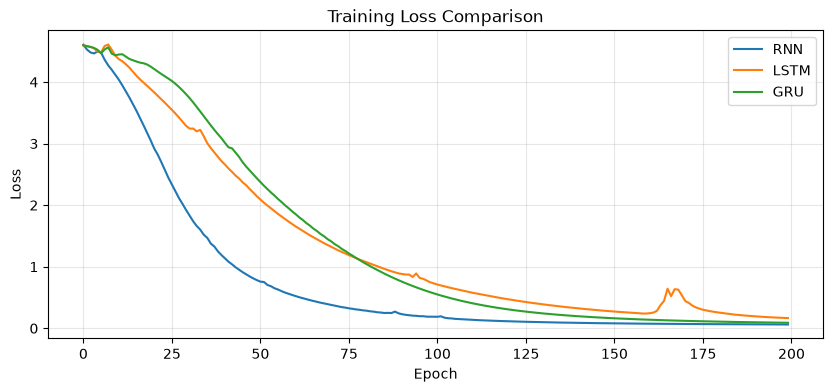

In [39]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'],label='RNN')
plt.plot(lstm_history.history['loss'],label='LSTM')
plt.plot(gru_history.history['loss'],label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Observations
- RNN has the lowest loss throughout training
- since the dataset is small and contains shorter sequences RNN is sufficient and even easier to optimize

- GRU starts extremely poorly but eventually catches up
- GRU takes much longer to converge


## Compare Training Accuracy

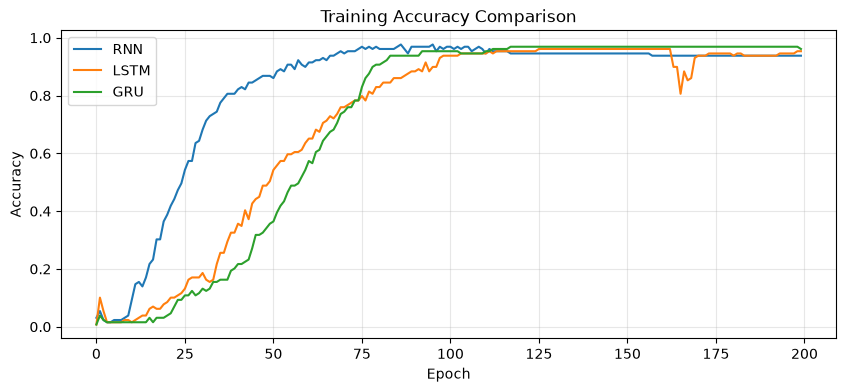

In [40]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['accuracy'],label='RNN')
plt.plot(lstm_history.history['accuracy'],label='LSTM')
plt.plot(gru_history.history['accuracy'],label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Observation:**
- Around epochs 100–125, the GRU curve catches up to the LSTM curve
- Vanilla RNN curve is almost flat,indicating very fast convergence
- LSTM starts with high accuracy, eventually stabilizes around 96–97%
- GRU starts near 0% accuracy,unlike RNN and LSTM and has rapid S-shaped increase

##  Text Generation Function
**The steps involved in text genration function are**

1. Take the current `seed_text`,tokenize it into integers
2. Pad it to match the input length the model expects
3. Ask the model to predict the next word
4. Look up that index back into a word, append it to `seed_text`
5. Repeat—the newly generated word becomes part of the input for the next prediction

In [42]:
def generate_text(model,seed_text,next_words=10):
    for _ in range(next_words):
        token_list=token.texts_to_sequences([seed_text])[0]
        token_list=pad_sequences([token_list],maxlen=max_len-1,padding='pre')
        predicted=np.argmax(model.predict(token_list,verbose=0),axis=-1)[0]
        output_word=""
        for word,index in token.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text+= " "+output_word
    return seed_text

## Generate Text Samples

In [44]:
print("RNN :", generate_text(rnn_model,"deep learning",10))
print("LSTM:", generate_text(lstm_model,"deep learning",10))
print("GRU :", generate_text(gru_model,"deep learning",10))

#predicitng "gru is"
print("RNN :", generate_text(rnn_model,"gru is",10))
print("LSTM:", generate_text(lstm_model,"gru is",10))
print("GRU :", generate_text(gru_model,"gru is",10))

RNN : deep learning is transforming artificial intelligence sentences generate a sequence generate are
LSTM: deep learning models can generate meaningful sentences sentences a a sequence instead
GRU : deep learning is transforming artificial intelligence intelligence intelligence intelligence intelligence similarly similarly
RNN : gru is faster and simpler than lstm but performs similarly and three
LSTM: gru is faster and simpler than lstm but performs similarly similarly flow
GRU : gru is faster and simpler than lstm but performs similarly similarly similarly


In [ ]:
print("RNN :",generate_text(rnn_model, "lstm helps",10))
print("LSTM:",generate_text(lstm_model, "lstm helps",10))
print("GRU :",generate_text(gru_model, "lstm helps",10))

RNN : lstm helps remember long term dependencies in text vanishing gradients sequence in
LSTM: lstm helps remember long term dependencies in text text vanishing gradients gradients
GRU : lstm helps remember long term dependencies in text text text text systems


**Observation:**
- LSTM produced the most natural sentences
- LSTM outputs maintain grammatical structure,avoid excessive repetition
- GRU showed noticeable repetition
- RNN captured local patterns effectively
- In RNN some transitions between words were unnatural
- RNN still performed reasonably well is that the dataset contains short sentences with limited long-term dependencies

### Final Conclusions

- Increasing model capacity improved performance this indicates that larger embeddings captured richer semantic information,while more hidden units increased the network's ability to model sequential patterns.

 **The training curves showed that**
- RNN reached high accuracy within the first few epochs
- LSTM converged slightly later
- GRU required many more epochs before matching the performance with other two models

**On text sample generation**
- LSTM produced the most grammatically meaningful sentences.
- GRU occasionally repeated words such as "similarly" and "text".
- RNN performed almost equally compared to other models because of small corpus size,short sentence lengths,limited vocabulary